In July 2026, a 30-day experiment was conducted to evaluate the implementation of a **new AI-powered recommendation model on the homepage**. The new model was designed to deliver more personalized product recommendations based on users’ preferences.

**Experiment duration: 30 days**

# **1. Metrics Analysis**

The goal of the new recommendation system is to provide users with more relevant product suggestions at the product impression stage.

Using the metric tree, we will define the key product success metrics that may be affected by the experiment:


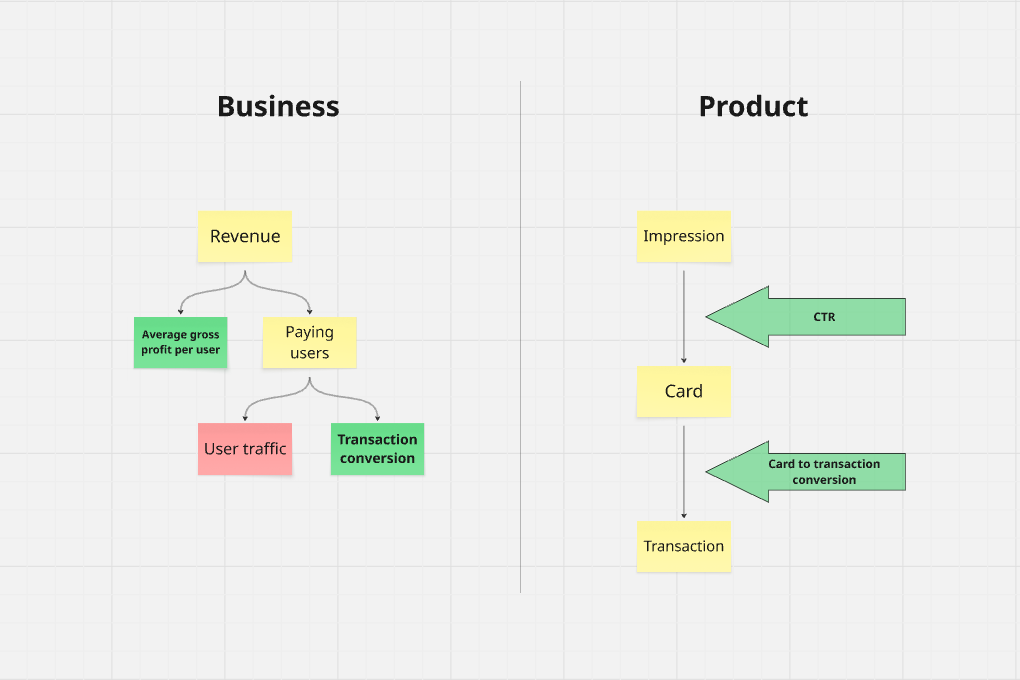

* The primary business metric is **Average GMV per User**.
* The primary product metric is **Impression-to-Purchase Conversion Rate**.
* The experiment’s target metric is **Impression-to-Click Conversion Rate (CTR)**.

We will also introduce additional monitoring metrics to provide a more comprehensive view of the experiment’s impact.

| Role      | Metric                                   | Aspect of the Experiment                          |
| --------- | ---------------------------------------- | ------------------------------------------------- |
| Primary   | Gross Margin per User                    | Overall financial impact                          |
| Proxy     | Recommendation CTR                       | Early indicator of recommendation relevance       |
| Proxy     | User-to-Purchase Conversion Rate         | Impact of recommendations on purchasing behaviour |
| Proxy     | Share of Users with Two or More Orders   | Early indicator of repeat purchasing behaviour    |
| Guardrail | Product Card-to-Purchase Conversion Rate | Comparison against the baseline conversion rate   |
| Guardrail | Return Rate                              | Quality and relevance of completed purchases      |
| Guardrail | Support Tickets per 100 Orders           | Frequency of customer experience issues           |



# **2. EDA**

In [1]:
import sqlalchemy
import pandas as pd
from sqlalchemy import text
import seaborn as sns
import matplotlib.pyplot as plt

from db_conn import create_engine_custom

# Connecting to the DB
DB_name = 'market_flow'
engine, _ = create_engine_custom(DB_name)

market_flow DB exists already


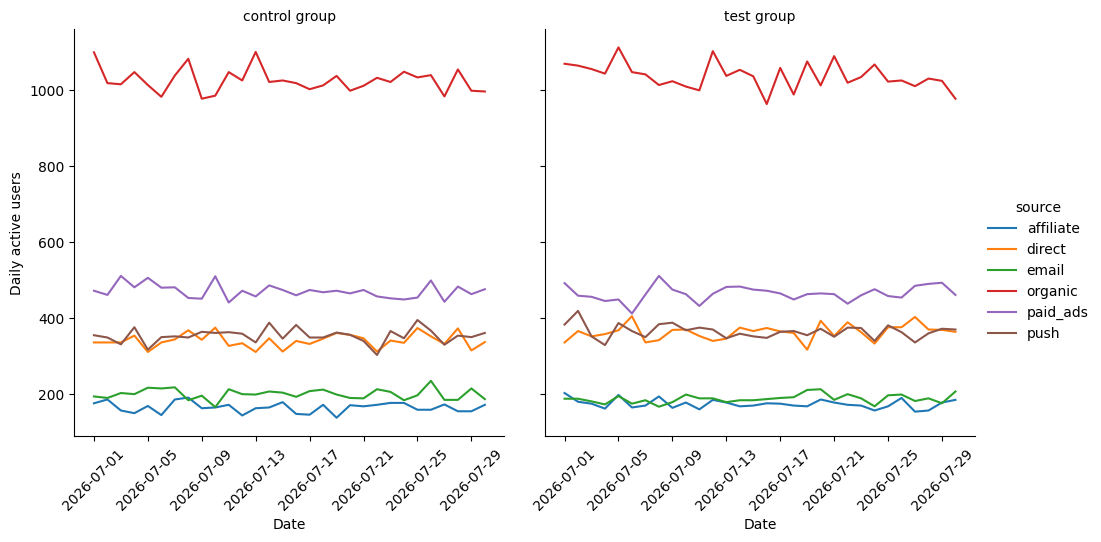

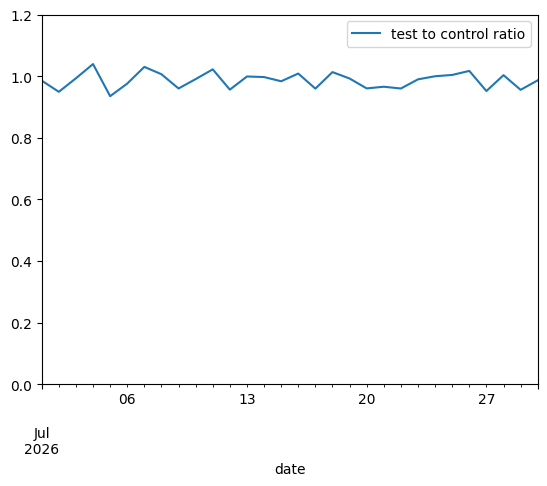

In [2]:

# Traffic distribution

with engine.connect() as conn:
    result = pd.read_sql(text("""
        SELECT 
            s.session_date as date,
            eu.experiment_group as group,
            u.traffic_source as source,
            COUNT(DISTINCT u.user_id) as num_users,
            COUNT(DISTINCT s.session_id) as num_sessions
        FROM sessions s
        JOIN experiment_assignment eu
            ON eu.user_id = s.user_id
        JOIN users u
            ON s.user_id = u.user_id
        GROUP BY s.session_date, eu.experiment_group, u.traffic_source
    """), conn)
    
g = sns.relplot(
    data=result,
    x='date',
    y='num_users',
    hue='source',
    kind='line',
    col='group'
)

g.set_axis_labels('Date', "Daily active users")
g.set_titles ('{col_name} group')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

test_to_ctrl_ratio = (result.groupby(['date', 'group'])
    .agg(test=('num_users', 'sum')).
    pivot_table(values='test',
                index='date',
                columns='group'))

test_to_ctrl_ratio['test to control ratio'] = test_to_ctrl_ratio['control'] / test_to_ctrl_ratio['test']
test_to_ctrl_ratio.plot(y='test to control ratio', kind='line',ylim=(0,1.2));

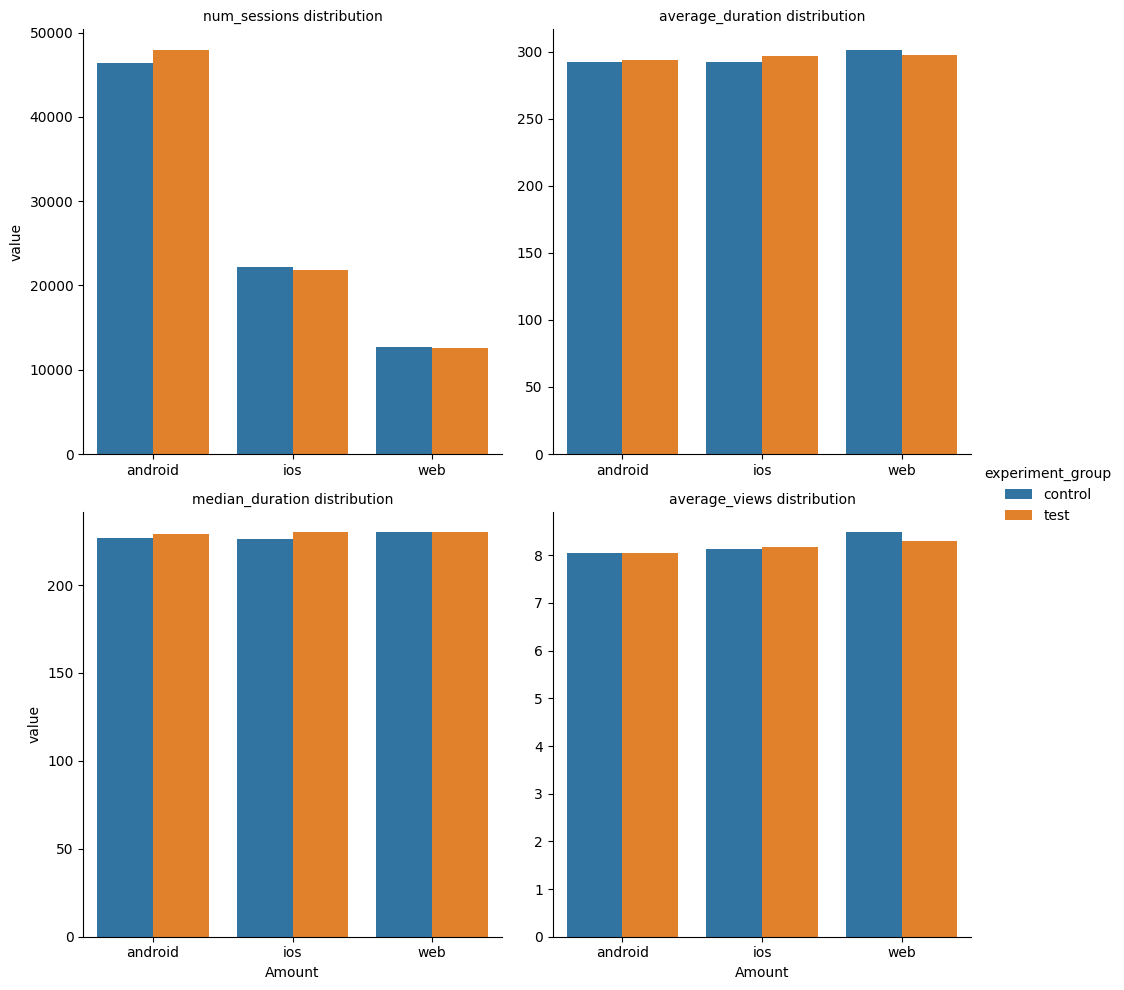

In [3]:
# Session quality

with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT 
                s.device,
                eu.experiment_group,
                COUNT(DISTINCT s.session_id) as num_sessions,
                AVG(s.session_duration_sec) as average_duration,
                PERCENTILE_CONT(0.5) 
                    WITHIN GROUP (ORDER BY s.session_duration_sec) as median_duration,
                AVG(s.page_views) as average_views
            FROM sessions s
            INNER JOIN experiment_assignment eu
                ON eu.user_id = s.user_id
            GROUP BY s.device, eu.experiment_group
        """),
        conn
    )

g = sns.catplot(
    x='device',
    y='value',
    data=result.melt(('device', 'experiment_group')),
    kind='bar',
    hue='experiment_group',
    col='variable',
    col_wrap=2,
    sharex=False,
    sharey=False
)

g.set_axis_labels(x_var='Amount')
g.set_titles('{col_name} distribution');

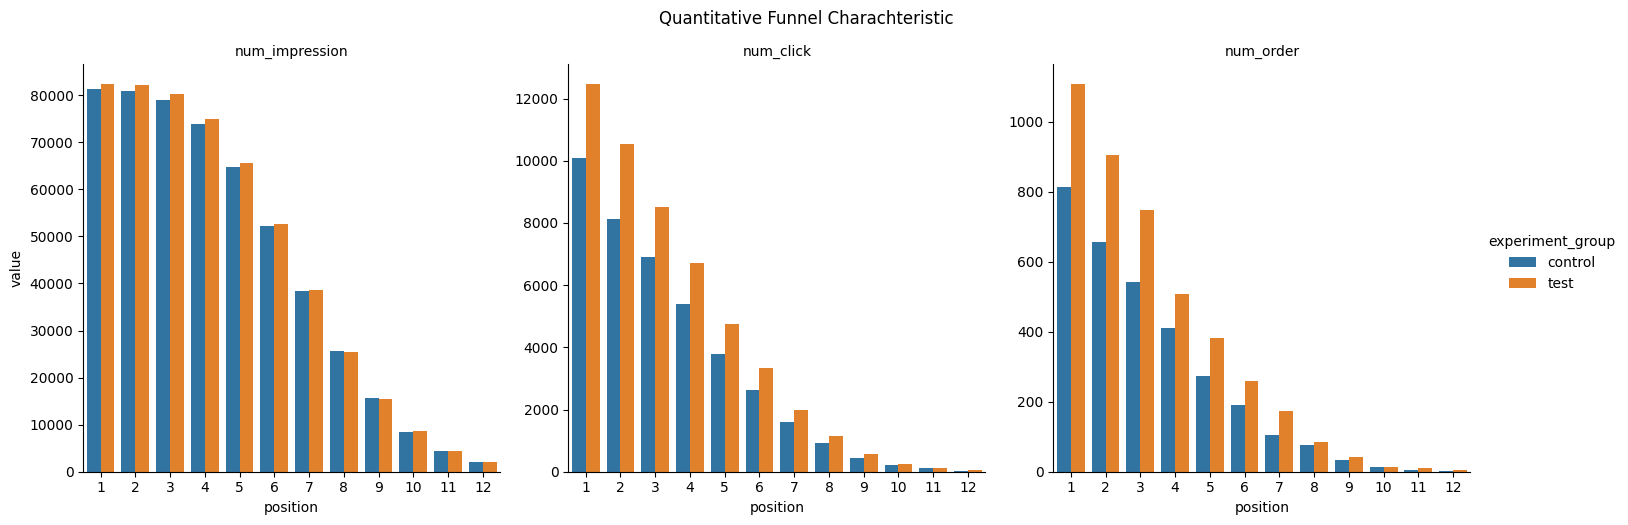

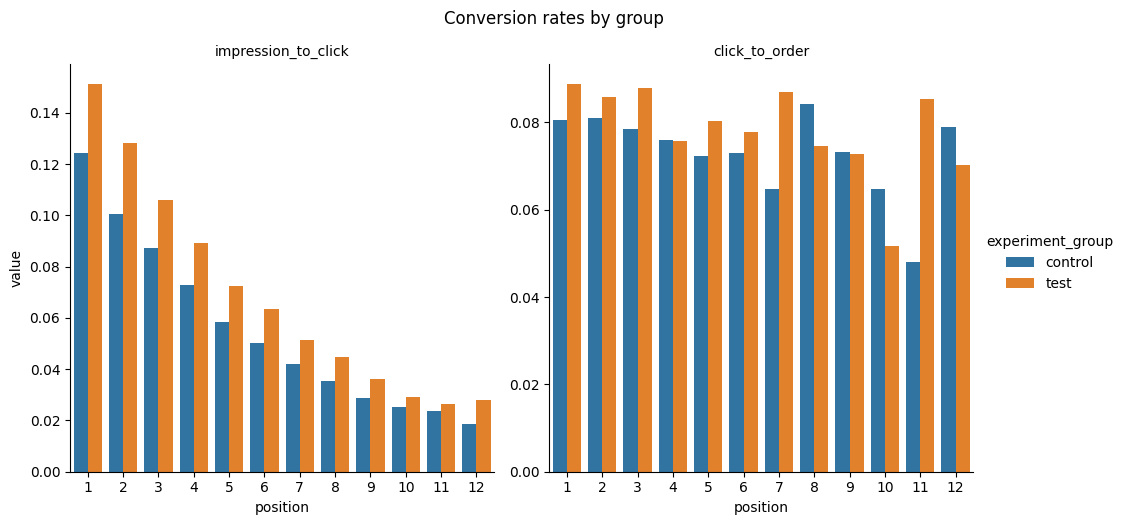

In [4]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH funnel_data AS(
                SELECT
                    eu.experiment_group,
                    i.position,
                    COUNT(DISTINCT i.impression_id) as num_impression,
                    COUNT(DISTINCT c.click_id) as num_click,
                    COUNT(DISTINCT o.order_id) as num_order
                FROM impressions i
                LEFT JOIN clicks c
                    ON i.impression_id = c.impression_id
                LEFT JOIN orders o
                    ON o.click_id = c.click_id
                JOIN experiment_assignment eu
                    ON i.user_id = eu.user_id
                GROUP BY eu.experiment_group, i.position
            )
            SELECT
                *,
                num_click::float / num_impression as impression_to_click,
                num_order::float / num_click as click_to_order
            FROM funnel_data
        """), conn
    )

num_df = result[['experiment_group', 'position', 'num_impression', 'num_click', 'num_order']]

g1 = sns.catplot(
    data=num_df.melt(id_vars=('experiment_group', 'position')),
    hue='experiment_group',
    y='value',
    x='position',
    col='variable',
    kind='bar',
    sharey=False
)
g1.fig.suptitle('Quantitative Funnel Charachteristic', y=1.04)
g1.set_titles('{col_name}')


ratio_df = result[['experiment_group', 'position', 'impression_to_click', 'click_to_order']]
g2 = sns.catplot(
    data=ratio_df.melt(id_vars=('experiment_group', 'position')),
    hue='experiment_group',
    y='value',
    x='position',
    col='variable',
    kind='bar',
    sharey=False
)
g2.fig.suptitle('Conversion rates by group', y=1.04)
g2.set_titles('{col_name}');

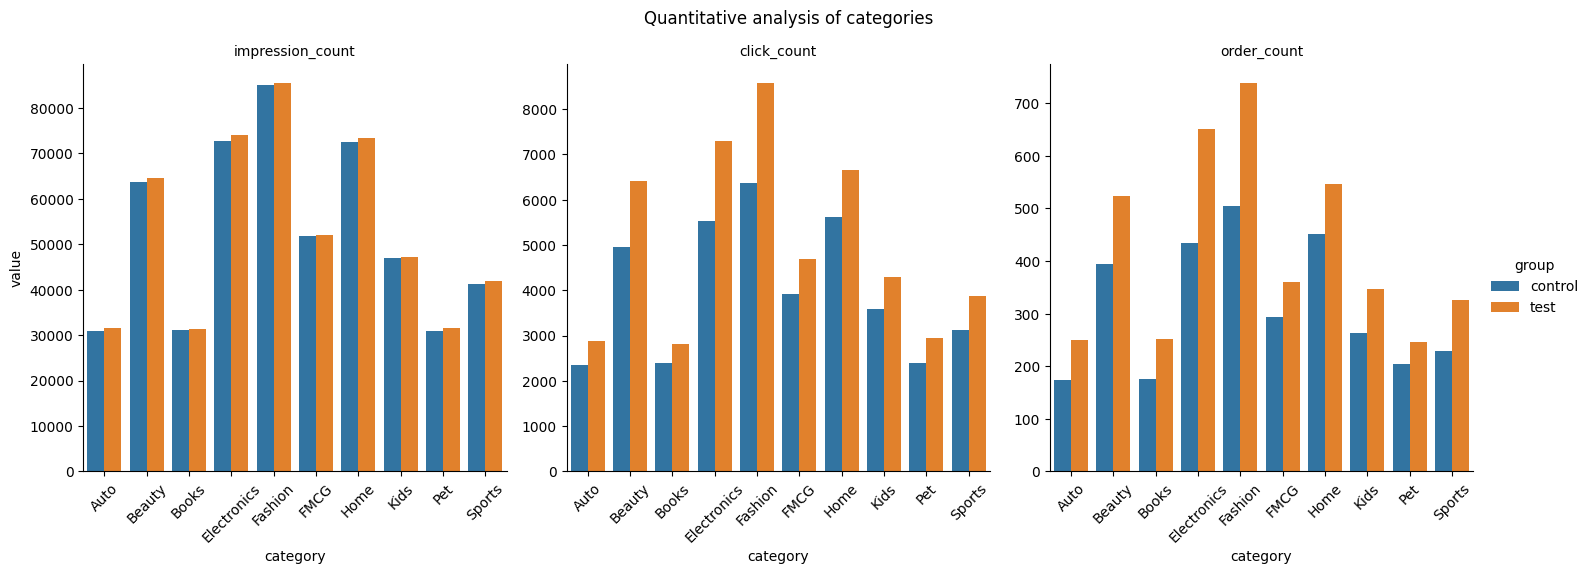

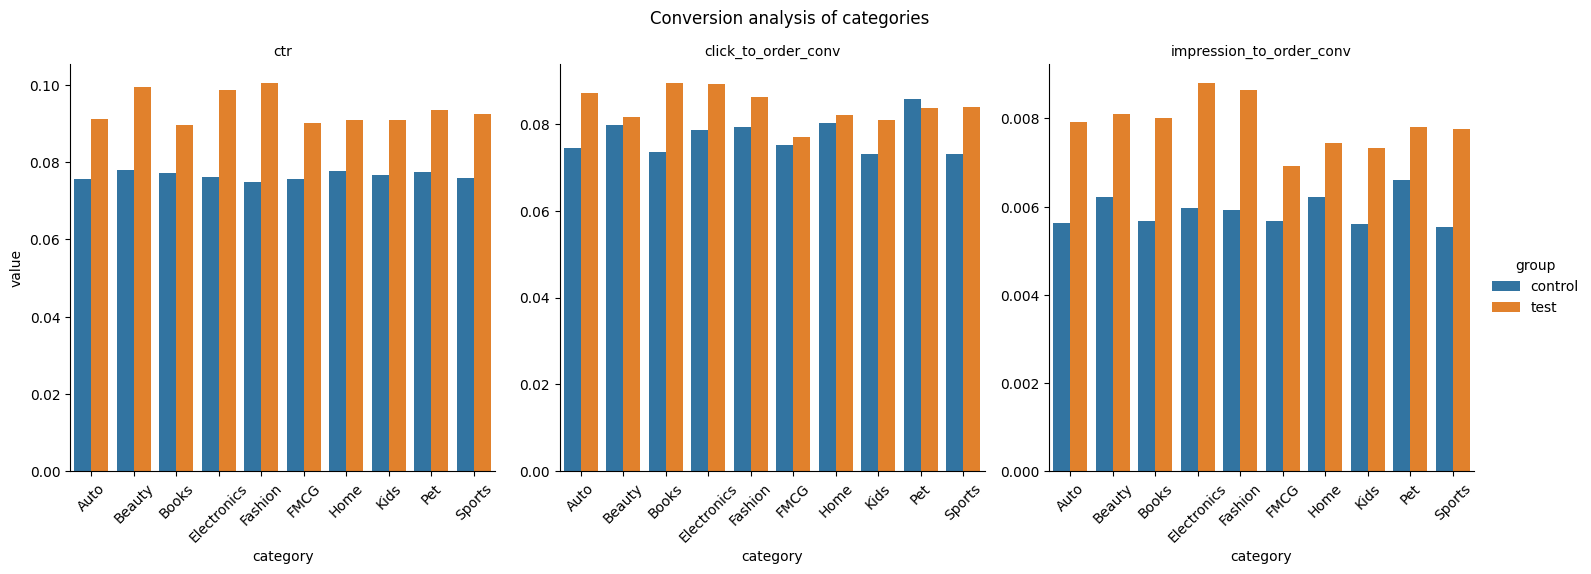

In [5]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH cat_analysis AS (
                SELECT
                    ea.experiment_group as group,
                    p.category,
                    COUNT(DISTINCT i.impression_id) as impression_count,
                    COUNT(DISTINCT c.click_id) as click_count,
                    COUNT(DISTINCT o.order_id) as order_count
                FROM impressions i
                LEFT JOIN products p
                    ON i.product_id = p.product_id
                LEFT JOIN clicks c
                    ON i.impression_id = c.impression_id
                LEFT JOIN orders o
                    ON o.click_id = c.click_id
                JOIN experiment_assignment ea
                    ON i.user_id = ea.user_id
                GROUP BY ea.experiment_group, p.category
            )
            SELECT 
                *,
                click_count::float / NULLIF(impression_count, 0) as CTR,
                order_count::float / NULLIF(click_count, 0) as click_to_order_conv,
                order_count::float / NULLIF(impression_count, 0) as impression_to_order_conv
            FROM cat_analysis
        """), conn
    )

count_df = (result[['group', 'category', 'impression_count', 
                    'click_count', 'order_count']]
                    .melt(id_vars=('group', 'category')))
count_df
g1 = sns.catplot(
    data=count_df,
    x='category',
    y='value',
    col='variable',
    hue='group',
    kind='bar',
    sharey=False
)
g1.fig.suptitle('Quantitative analysis of categories', y=1.04)
g1.set_titles('{col_name}')
g1.set_xticklabels(rotation=45);

count_df = (result[['group', 'category', 'ctr',
                     'click_to_order_conv', 'impression_to_order_conv']]
                    .melt(id_vars=('group', 'category')))
count_df
g2 = sns.catplot(
    data=count_df,
    x='category',
    y='value',
    col='variable',
    hue='group',
    kind='bar',
    sharey=False
)
g2.fig.suptitle('Conversion analysis of categories', y=1.04)
g2.set_titles('{col_name}')
g2.set_xticklabels(rotation=45);

amount  ratio
group   is_returned               
control 0              2954  94.5%
        1               172   5.5%
test    0              3948  93.2%
        1               289   6.8%

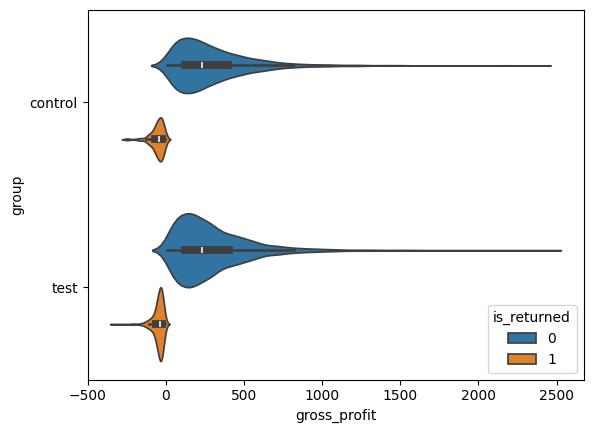

In [6]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT 
                ea.experiment_group as group,
                o.user_id,
                gross_margin_rub as gross_profit,
                is_returned
            FROM orders o
            JOIN experiment_assignment ea
                ON o.user_id = ea.user_id
        """), conn
    )


df = result.groupby(['group', 'is_returned']).agg(median=('gross_profit', 'median'), amount=('gross_profit', 'count'))

df['group_total'] = df.groupby('group')['amount'].transform('sum')
df['ratio'] = (df.amount / df.group_total * 100).map('{:.1f}%'.format)
display(df[['amount', 'ratio']])

sns.violinplot(
    data=result,
    y='group',
    x='gross_profit',
    hue='is_returned',
    density_norm='count'
);



Text(0.5, 1.04, 'Order frequency analysis')

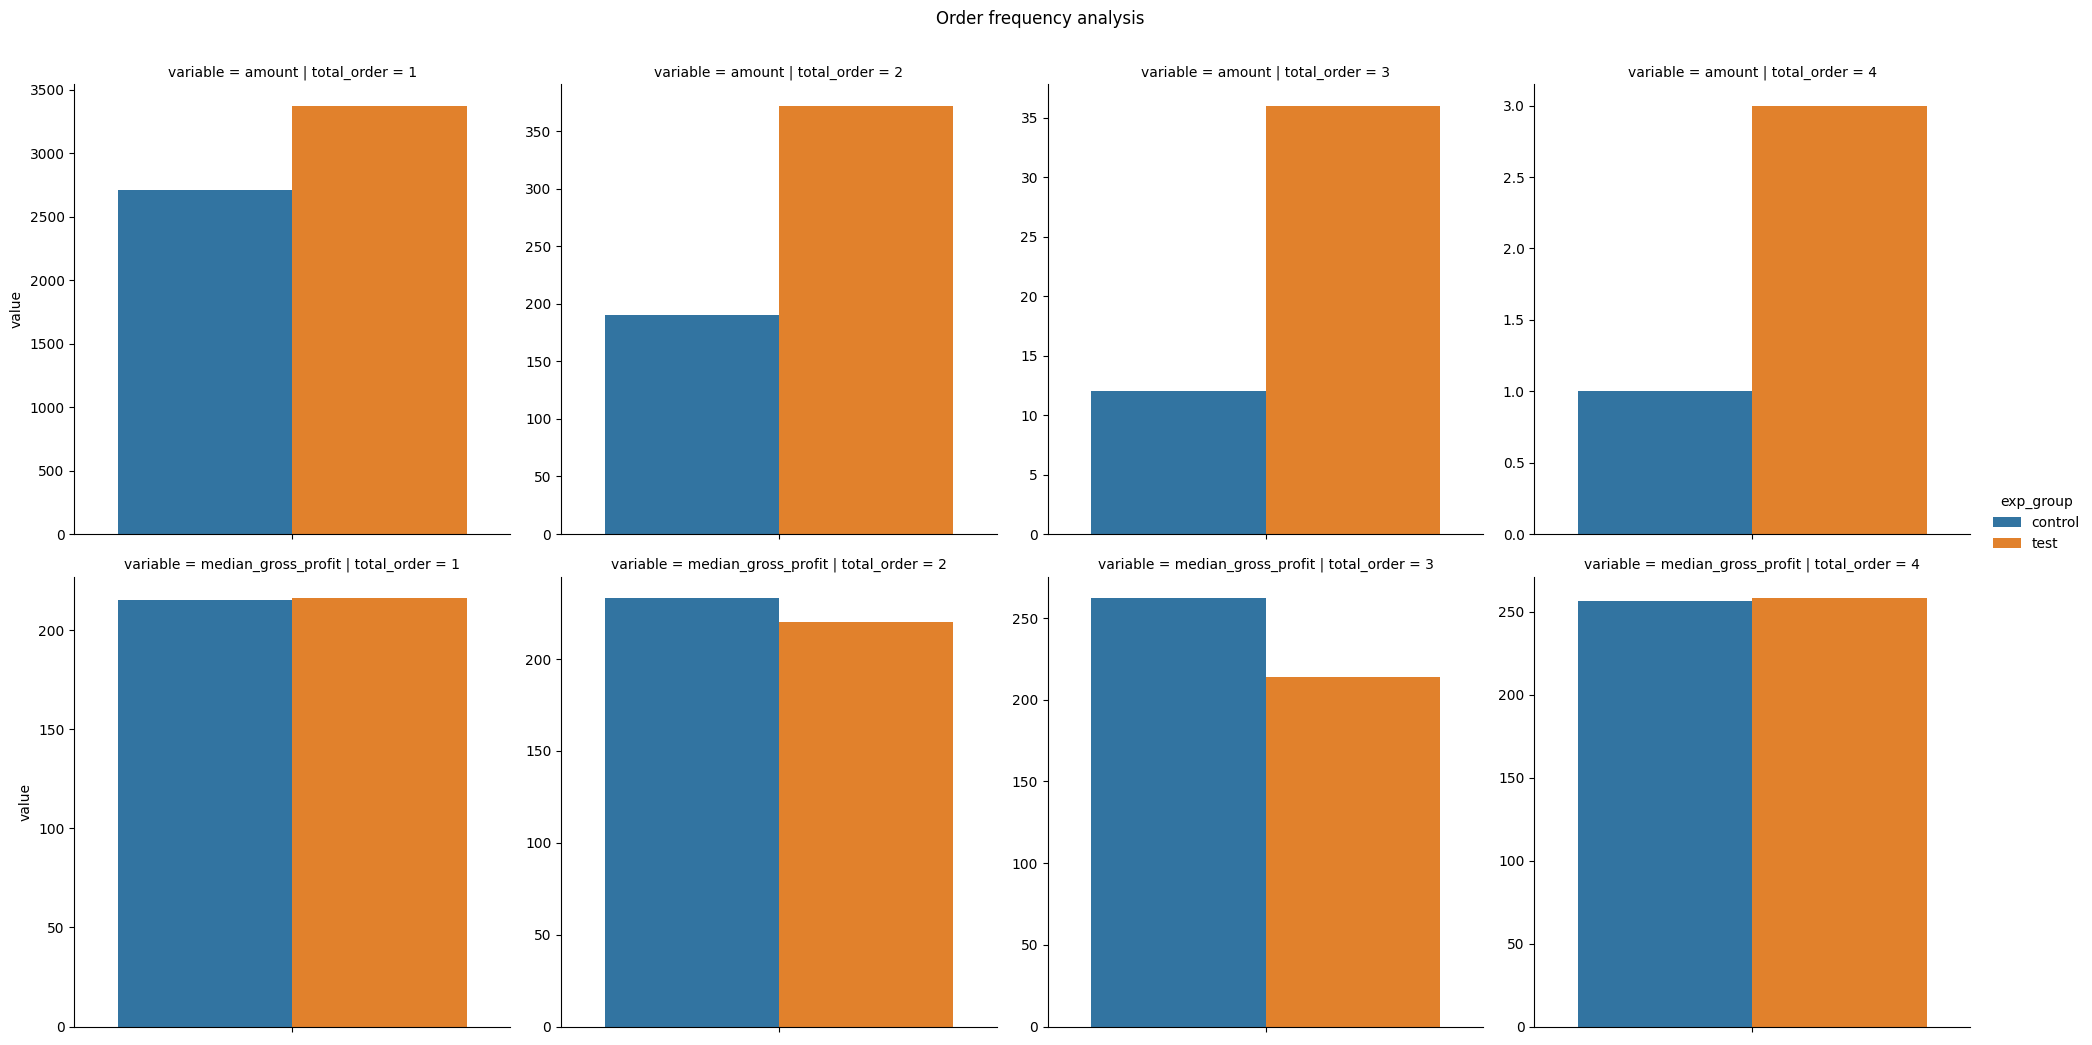

In [7]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH order_dt AS (
                SELECT 
                    ea.experiment_group as exp_group,
                    o.user_id,
                    SUM(gross_margin_rub) as total_gross_profit,
                    COUNT(DISTINCT o.order_id) as total_order
                FROM orders o
                JOIN experiment_assignment ea
                    ON o.user_id = ea.user_id
                GROUP BY ea.experiment_group, o.user_id
            )
            SELECT 
                exp_group,
                total_order,
                PERCENTILE_CONT(0.5) WITHIN GROUP 
                    (ORDER BY total_gross_profit / NULLIF(total_order, 0)
                    ) as median_gross_profit,
                COUNT(user_id) as amount
            FROM order_dt
            GROUP BY exp_group, total_order
        """), conn
    )

g = sns.catplot(
    data=result.melt(id_vars=['exp_group', 'total_order']),
    y='value',
    hue='exp_group',
    col='total_order',
    row='variable',
    row_order=['amount', 'median_gross_profit'],
    kind='bar',
    sharey=False
)

g.fig.suptitle('Order frequency analysis', y=1.04)


In [8]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH order_stat AS (
                SELECT
                    ea.experiment_group as exp_group,
                    o.order_date,
                    COUNT(*) as user_traffic,
                    SUM(o.gross_margin_rub) as total,
                    AVG(o.is_returned) * 100 as return_rate
                FROM orders o
                JOIN experiment_assignment ea
                    ON ea.user_id = o.user_id
                GROUP BY ea.experiment_group, o.order_date
            )
            SELECT
                exp_group,
                order_date,
                user_traffic,
                EXTRACT (ISODOW FROM order_date),
                return_rate,
                AVG(total) OVER (
                    PARTITION BY exp_group
                    ORDER BY order_date
                    ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
                ) 
                / 
                NULLIF (
                    AVG(user_traffic) OVER (
                        PARTITION BY exp_group
                        ORDER BY order_date
                        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW),
                0) as rolling_7d_profit
            FROM order_stat
            ORDER BY exp_group, order_date
        """), conn
    )

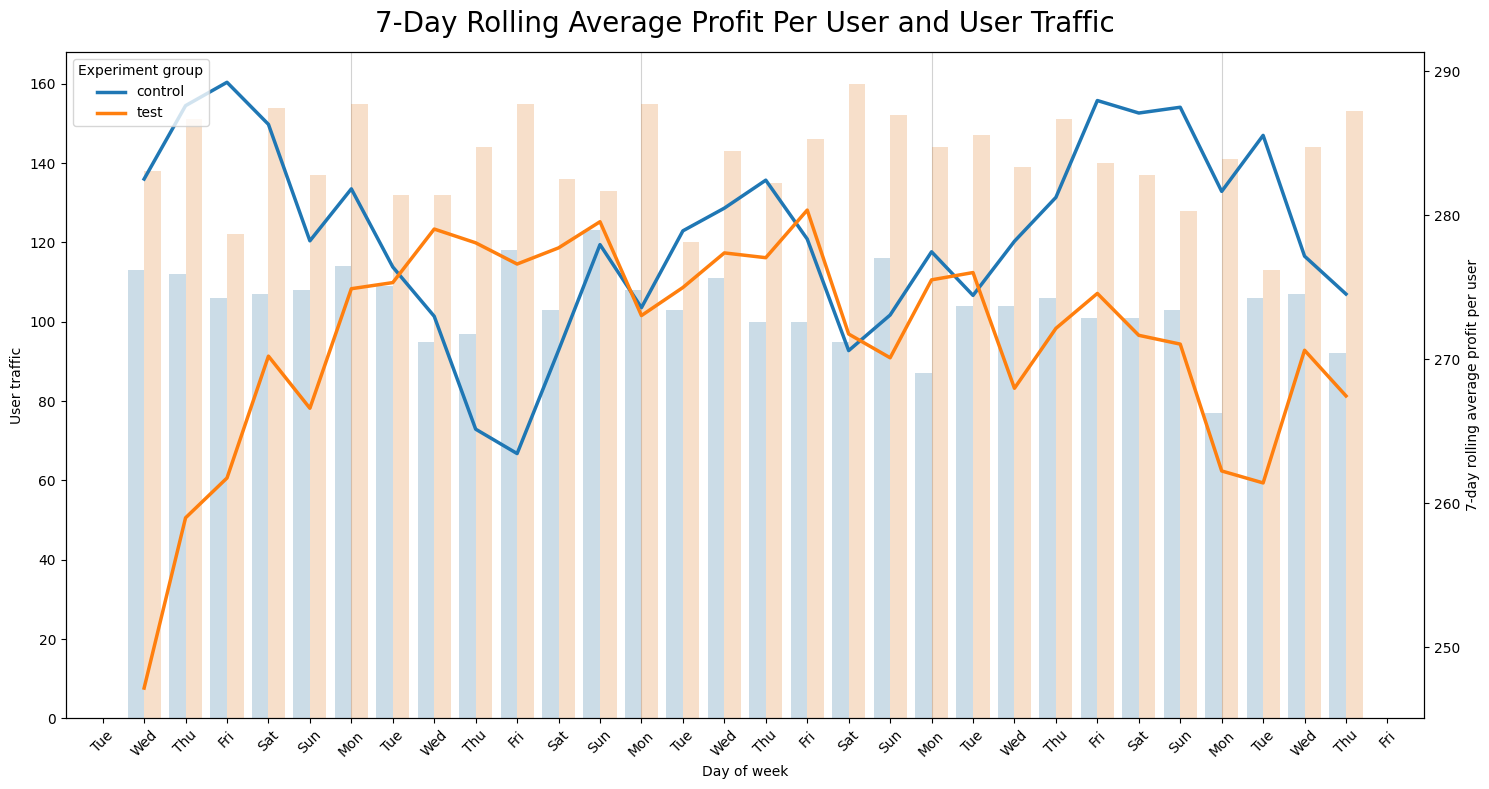

In [9]:
import matplotlib.dates as mdates

result['order_date'] = pd.to_datetime(result['order_date'])

fig, ax_traffic = plt.subplots(figsize=(15, 8))
ax_profit = ax_traffic.twinx()

sns.barplot(
    data=result,
    x='order_date',
    y='user_traffic',
    hue='exp_group',
    alpha=0.25,
    errorbar=None,
    native_scale=True,
    ax=ax_traffic
)

sns.lineplot(
    data=result,
    x='order_date',
    y='rolling_7d_profit',
    hue='exp_group',
    linewidth=2.5,
    ax=ax_profit
)

ax_traffic.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax_traffic.xaxis.set_major_formatter(mdates.DateFormatter('%a'))
ax_traffic.tick_params(axis='x', labelrotation=45)

mondays = (
    result.loc[
        result['order_date'].dt.weekday == 0,
        'order_date'
    ]
    .drop_duplicates()
)

for monday in mondays:
    ax_traffic.axvline(
        monday,
        color='gray',
        linewidth=0.8,
        alpha=0.35,
        zorder=0
    )

ax_traffic.set_xlabel('Day of week')
ax_traffic.set_ylabel('User traffic')
ax_profit.set_ylabel('7-day rolling average profit per user')

traffic_handles, traffic_labels = ax_traffic.get_legend_handles_labels()
profit_handles, profit_labels = ax_profit.get_legend_handles_labels()

ax_traffic.legend_.remove()
ax_profit.legend_.remove()

ax_profit.legend(
    profit_handles,
    profit_labels,
    title='Experiment group',
    loc='upper left'
)

fig.suptitle(
    '7-Day Rolling Average Profit Per User and User Traffic',
    fontsize=20
)

fig.tight_layout()
plt.show()

C:\Users\BULOCHKA\AppData\Local\Temp\ipykernel_17212\372363715.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g=sns.barplot(
C:\Users\BULOCHKA\AppData\Local\Temp\ipykernel_17212\372363715.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=result.category, rotation=45);


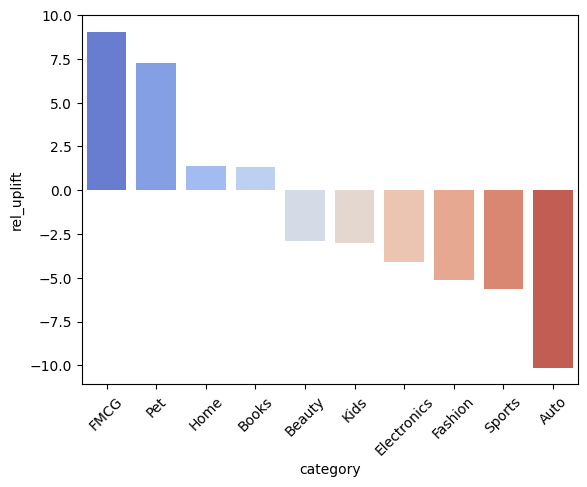

In [37]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH cat_data AS (
                SELECT
                    ea.experiment_group as exp_group,
                    p.category,
                    AVG(o.gross_margin_rub) as avg_profit,
                    RANK() OVER (
                        PARTITION BY ea.experiment_group
                        ORDER BY AVG(o.gross_margin_rub) DESC
                    ) as rank
                FROM orders o
                JOIN products p
                    ON p.product_id = o.product_id
                JOIN experiment_assignment ea
                    ON o.user_id = ea.user_id
                GROUP BY ea.experiment_group, p.category
                ORDER BY exp_group, avg_profit DESC
            )
            SELECT
                c1.category,
                c1.avg_profit as avg_profit_control,
                c2.avg_profit as avg_profit_test,
                c2.avg_profit - c1.avg_profit as uplift,
                (c2.avg_profit - c1.avg_profit)::float / c1.avg_profit * 100 as rel_uplift,
                RANK() OVER(
                    ORDER BY (c2.avg_profit - c1.avg_profit)::float / c1.avg_profit * 100 DESC)
            FROM cat_data c1
            JOIN cat_data c2
                ON c1.category = c2.category
                    AND c2.exp_group='test'
                    AND c1.exp_group='control'
        """), conn
    )

g=sns.barplot(
    data=result,
    y='rel_uplift',
    x='category',
    palette='coolwarm'
)

g.set_xticklabels(labels=result.category, rotation=45);

In [44]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT
                u.user_id,
                u.registration_date,
                DATE_TRUNC('day', event_time) as event_time

            FROM clicks c
            LEFT JOIN users u
                ON u.user_id = c.user_id
            JOIN experiment_assignment ea
                ON ea.user_id = c.user_id
        """),conn
    )
result

,user_id,registration_date,event_time
0,u_000001,2026-04-29,2026-07-24
1,u_000003,2026-04-01,2026-07-14
2,u_000005,2025-07-28,2026-07-20
3,u_000006,2025-08-01,2026-07-21
4,u_000006,2025-08-01,2026-07-21
...,...,...,...
90691,u_049998,2026-05-04,2026-07-13
90692,u_049999,2026-01-04,2026-07-14
90693,u_049999,2026-01-04,2026-07-14
90694,u_049999,2026-01-04,2026-07-04
